In [1]:
import os
import tifffile
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from skimage.draw import polygon
from matplotlib.collections import LineCollection
import pandas as pd
import numpy as np
import seaborn as sns
import json
from collections import defaultdict
from mmtrack import plot_cells
from pathlib import Path

In [2]:
# # code used to help me figure out which masks and kymos were avaiable 
# ROOT = Path("/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data")

# def check_experiments(root: Path):
#     results = []
#     for exp_dir in sorted([p for p in root.iterdir() if p.is_dir()]):
#         experiment_name = exp_dir.name
#         base_path = exp_dir / "hyperstacked/drift_corrected/rotated/mm_channels/subtracted"

#         fluor_dir  = base_path / "fluor_kymos"
#         phase_dir  = base_path                  # phase stack dir is base_path
#         labels_dir = base_path / "mask_kymos"

#         def has_files(d: Path) -> bool:
#             return d.is_dir() and any(p.is_file() for p in d.iterdir())

#         results.append({
#             "experiment": experiment_name,
#             "fluor_dir_exists": fluor_dir.is_dir(),
#             "fluor_has_files": has_files(fluor_dir),
#             "phase_dir_exists": phase_dir.is_dir(),
#             "phase_has_files": has_files(phase_dir),
#             "labels_dir_exists": labels_dir.is_dir(),
#             "labels_has_files": has_files(labels_dir),
#         })
#     return results

# results = check_experiments(ROOT)

# # Print a compact report
# missing_any = []
# for r in results:
#     ok = (r["fluor_has_files"] and r["phase_has_files"] and r["labels_has_files"])
#     if not ok:
#         missing_any.append(r["experiment"])
#     print(
#         f'{r["experiment"]}: '
#         f'fluor={"OK" if r["fluor_has_files"] else "MISSING/EMPTY"}, '
#         f'phase={"OK" if r["phase_has_files"] else "MISSING/EMPTY"}, '
#         f'labels={"OK" if r["labels_has_files"] else "MISSING/EMPTY"}'
#     )

# print("\nExperiments missing/empty in at least one folder:")
# for e in missing_any:
#     print(" -", e)

In [3]:
# function that plots phase, fluor, and mask kymograph using current file naming standards
# uses post time_dict files 

def plot_all_functions(experiment):
    base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
    path_to_fluor_stack_dir=f'{base_path}/fluor_kymos'
    path_to_phase_stack_dir=f'{base_path}'
    path_to_labels_stack_dir =f'{base_path}/mask_kymos'
    phase_list = os.listdir(path_to_phase_stack_dir)
    mask_list =os.listdir(path_to_labels_stack_dir)
    fluor_list =os.listdir(path_to_fluor_stack_dir)
    tab20_cmap = plt.get_cmap("tab20")


    for file_name in mask_list:
        if file_name in phase_list and file_name in fluor_list:
            base_name = file_name.replace('.tif', '')
            path_to_mask_stack = f'{path_to_labels_stack_dir}/{file_name}'
            path_to_phase_stack = f'{path_to_phase_stack_dir}/{file_name}'
            path_to_fluor_stack =f'{path_to_fluor_stack_dir}/{file_name}'
            
            phase_kymograph=tifffile.imread(path_to_phase_stack)
            fluor_kymograph=tifffile.imread(path_to_fluor_stack)
            mask_kymograph=tifffile.imread(path_to_mask_stack)

            colored_mask = np.zeros((*mask_kymograph.shape, 4), dtype=np.float32)  
            unique_labels = np.unique(mask_kymograph)
            for label in unique_labels:
                if label > 0: 
                    mask_indices = (mask_kymograph == label)
                    colored_mask[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
                    colored_mask[mask_indices, 3] = 1.0  

            plt.figure(figsize=(12, 8))

            plt.subplot(1, 3, 1)
            plt.imshow(phase_kymograph, cmap='gray')
            plt.title(f'Phase {base_name}')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(phase_kymograph, cmap='gray')  
            plt.imshow(colored_mask, alpha=0.5)  
            plt.title(f'Mask {base_name}')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(fluor_kymograph, cmap='gray')  
            plt.title(f'Fluor {base_name}')
            plt.axis('off')
            
            plt.show()        

In [ ]:
# function that plots just segmented labels overlayed on phase image of kymograph
# note this uses segmentation after time_dict

def plot_mask(experiment):
    base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
    path_to_phase_stack_dir=f'{base_path}'
    path_to_labels_stack_dir =f'{base_path}/mask_kymos'
    phase_list = os.listdir(path_to_phase_stack_dir)
    mask_list =os.listdir(path_to_labels_stack_dir)
    tab20_cmap = plt.get_cmap("tab20")


    for file_name in mask_list:
        if file_name in phase_list:
            base_name = file_name.replace('.tif', '')
            path_to_mask_stack = f'{path_to_labels_stack_dir}/{file_name}'
            path_to_phase_stack = f'{path_to_phase_stack_dir}/{file_name}'
            
            phase_kymograph=tifffile.imread(path_to_phase_stack)
            mask_kymograph=tifffile.imread(path_to_mask_stack)

            colored_mask = np.zeros((*mask_kymograph.shape, 4), dtype=np.float32)  
            unique_labels = np.unique(mask_kymograph)
            for label in unique_labels:
                if label > 0: 
                    mask_indices = (mask_kymograph == label)
                    colored_mask[mask_indices, :3] = tab20_cmap(label % 20)[:3]  
                    colored_mask[mask_indices, 3] = 1.0  

            plt.figure(figsize=(12, 8))

            plt.imshow(phase_kymograph, cmap='gray')  
            plt.imshow(colored_mask, alpha=0.5)  
            plt.title(f'Mask {base_name}')
            plt.axis('off')
            
            # Show the plot
            plt.show()        

In [5]:
# function used to aid in plotting kymographs from Nora's notebook
def plot_kymograph_cells_id(phase_kymograph, fluor_kymograph, full_region_df, folder, fov_id, peak_id, track_id_col='track_id'):
    fig, ax = plt.subplots(1,1, figsize=(40, 10))

    # Get kymograph shape once for both calls
    kymograph_shape = phase_kymograph.shape
    print(kymograph_shape)

    ax.imshow(phase_kymograph, cmap = 'grey')
    plot_cells._plot_cell_masks(ax, full_region_df, kymograph_shape, y_coord_col = 'centroid_y', x_coord_col = 'centroid_x', lineage_col = track_id_col)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.set_title(f'Phase Kymograph - {folder} FOV: {fov_id}, trench: {peak_id}')

    plt.xlabel("Time frames")
    plt.tight_layout()

    plt.show()

# function used to plot centroids tracked. takes in the base_dir and a pandas dataframe 
# will plot all kymographs in pandas dataframe for testing use a subset dataframe before plotting everything
def plot_kymographs(base_dir, df_for_kymograph_plot):
    """Helper function to load kymograph images and plot predicted lineages."""
    print("\n--- Plotting Predicted Lineages on Kymographs ---")

    # Use pandas to get unique experiment/FOV/trench combinations
    unique_views = df_for_kymograph_plot[['experiment_name', 'FOV', 'trench_id']].drop_duplicates()

    if unique_views.empty:
        print("No unique views to plot.")
        return

    for index, cell_view in unique_views.iterrows():
        exp, fov, trench = cell_view['experiment_name'], cell_view['FOV'], cell_view['trench_id']

        # Path construction based on Stage 4's expected output
        kymo_base_path = os.path.join(base_dir, exp, 'hyperstacked', 'drift_corrected', 'rotated', 'mm_channels',
                                      'subtracted')

        # NOTE: Using the simple naming convention (e.g., '007_992.tif')
        path_to_phase_kymograph = os.path.join(kymo_base_path, f'{fov}_{trench}.tif')
        path_to_fluor_kymograph = os.path.join(kymo_base_path, 'fluor_kymos',
                                               f'{fov}_{trench}.tif')  # Assuming 'fluor' subdirectory

        # Fallback check for file existence
        if not (os.path.exists(path_to_phase_kymograph) and os.path.exists(path_to_fluor_kymograph)):
            print(f"  Skipping {exp}/{fov}/{trench}: Kymograph files not found.")
            continue

        print(f"  -> Plotting {exp}/{fov}/{trench}")

        phase_kymograph = tifffile.imread(path_to_phase_kymograph)
        fluor_kymograph = tifffile.imread(path_to_fluor_kymograph)

        df_view = df_for_kymograph_plot[
            (df_for_kymograph_plot['experiment_name'] == exp) &
            (df_for_kymograph_plot['FOV'] == fov) &
            (df_for_kymograph_plot['trench_id'] == trench)
            ].copy()

        plot_kymograph_cells_id(
            phase_kymograph, fluor_kymograph,
            df_view,
            exp, fov, trench,
            track_id_col='predicted_lineage'
        )


In [6]:
# Function used to detect fluorescent bursts in tracked data using mean fluroescence 
def detect_fluorescence_bursts_by_group(
    df: pd.DataFrame,
    fluor_col = 'intensity_mean_fluor',
    rolling_window_size: int = 6,
    std_dev_threshold: float = 2
) -> pd.DataFrame:
    """
    Detects fluorescence bursts for each unique experiment, FOV, and trench.

    Args:
        df (pd.DataFrame): The input DataFrame with 'experiment_name', 'FOV',
                           'trench_id', 'time_min', and 'mean_fluorescence' columns.
        rolling_window_size (int): The window size for the rolling filters
                                   (in number of time frames).
        std_dev_threshold (float): The number of standard deviations above the
                                   mean to be considered a significant burst.

    Returns:
        pd.DataFrame: The original DataFrame with new columns for burst detection.
    """
    processed_df_list = []

    # Group the DataFrame by the specified columns
    group_cols = ['gene', 'experiment_name', 'FOV']
    grouped_data = df.groupby(group_cols)

    for name, group in grouped_data:
        # Sort the group by time_frame to ensure rolling windows work correctly
        group = group.sort_values(by='time_frame')

        # Step 1: Baseline Subtraction (Local Baseline)
        group['local_min'] = group[fluor_col].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).min()
        
        group['normalized_fluorescence'] = group[fluor_col] - group['local_min']
        group['normalized_fluorescence'] = group['normalized_fluorescence'].clip(lower=0)

        # Step 2: Local Peak Detection
        group['local_max'] = group['normalized_fluorescence'].rolling(
            window=rolling_window_size,
            min_periods=1,
            center=True
        ).max()
        
        group['is_local_peak'] = (group['normalized_fluorescence'] == group['local_max'])

        # Step 3: Statistical Thresholding
        std_dev = group['normalized_fluorescence'].std()
        mean_signal = group['normalized_fluorescence'].mean()
        
        threshold = mean_signal + (std_dev_threshold * std_dev)

        group['is_burst'] = (group['is_local_peak']) & (group['normalized_fluorescence'] > threshold)

        processed_df_list.append(group)

    result_df = pd.concat(processed_df_list).reset_index(drop=True)
    
    # Remove temporary columns
    result_df = result_df.drop(columns=['local_min', 'local_max', 'is_local_peak'])

    return result_df

# used to merge dicts, needed to combine prior dictionaries from Nora and different batches of data
def merge_dicts(dict1, dict2):
    merged = defaultdict(dict)
    
    for key in dict1.keys():
        if key in dict2:
            # Merge if key exists in both dictionaries
            for subkey, values in dict1[key].items():
                if subkey in dict2[key]:
                    # Combine the lists for subkey
                    merged[key][subkey] = list(set(values + dict2[key][subkey]))
                else:
                    merged[key][subkey] = values
            for subkey, values in dict2[key].items():
                if subkey not in merged[key]:
                    merged[key][subkey] = values
        else:
            merged[key] = dict1[key]
    
    for key in dict2.keys():
        if key not in merged:
            merged[key] = dict2[key]
    
    return dict(merged)

In [7]:
#miscellaneous information needed for some dictionaries 
minutes_interval = {"DUMM_giTG62_Glucose_012925":5,
"DUMM_giTG66_Glucose_012325":5,
"DUMM_giTG059_noKan_Glucose_031125":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG064_Glucose_022625":5,
"DUMM_giTG69_Glucose_013025":5,
"DUMM_giTG068_063_061725_v2":10,
"DUMM_giTG63_giTG67_Glucose_121724_1_v2":5,
"DUMM_giTG059_060_061125":10,
"DUMM_giTG068_052925":5,
"DUMM_giTG068_063_061725":10,
"DUMM_CL008_giTG061_081225":10,
"DUMM_alkA_chpS_111325":10,
"DUMM_giTG062_064_121325":10,
"DUMM_gitg068_baeS_100225":10,
"DUMM_baeS_gfcE_112025":10,
"DUMM_giTG066_063_120925":10,
"DUMM_giTG060_064_121425":10,
"DUMM_giTG069_063_121125":10,
"DUMM_giTG069_063_121225":10,
"DUMM_mazF_murQ_121625":10,
"DUMM_giTG059_068_SC_093025":10,
"CL008_giTG068_072925":10
}

combined_dict ={'chpS': {'DUMM_giTG62_Glucose_012925': ['005'], 'DUMM_alkA_chpS_111325': ['003', '005', '006', '007', '009', '010', '011'], 'DUMM_giTG062_064_121325': ['005', '010', '012']}, 'baeS': {'DUMM_giTG66_Glucose_012325': ['003'], 'DUMM_gitg068_baeS_100225': ['013', '017', '018', '019', '020', '021', '022', '023'], 'DUMM_baeS_gfcE_112025': ['005'], 'DUMM_giTG066_063_120925': ['002', '007']}, 'lacZ': {'DUMM_giTG059_noKan_Glucose_031125': ['004'], 'DUMM_giTG059_060_061125': ['008'], 'DUMM_giTG059_068_SC_093025': ['015', '020']}, 'gfcE': {'DUMM_giTG064_Glucose_022625': ['001', '015'], 'DUMM_baeS_gfcE_112025': ['011', '012', '016'], 'DUMM_giTG062_064_121325': ['015', '019'], 'DUMM_giTG060_064_121425': ['013', '014', '020', '022']}, 'gldA': {'DUMM_giTG69_Glucose_013025': ['007'], 'DUMM_giTG069_063_121125': ['013', '016', '022', '025'], 'DUMM_giTG069_063_121225': ['013', '018', '022']}, 'alkA': {'DUMM_giTG068_063_061725_v2': ['000'], 'DUMM_giTG63_giTG67_Glucose_121724_1_v2': ['006'], 'DUMM_alkA_chpS_111325': ['017', '018', '022', '023'], 'DUMM_giTG066_063_120925': ['018', '019'], 'DUMM_giTG069_063_121125': ['001', '005', '006', '008'], 'DUMM_giTG069_063_121225': ['000']}, 'mazF': {'DUMM_giTG059_060_061125': ['015'], 'DUMM_giTG060_064_121425': ['000', '005'], 'DUMM_mazF_murQ_121625': ['005', '006', '012']}, 'hupA': {'DUMM_giTG068_052925': ['005'], 'DUMM_giTG068_063_061725': ['012']}, 'araB': {'DUMM_CL008_giTG061_081225': ['015', '016', '017', '018', '019', '020'], 'CL008_giTG068_072925': ['003', '007', '009']}, 'murQ': {'DUMM_mazF_murQ_121625': ['017', '018']}} 

exposure_dict= {'CL008_giTG068_072925': [45, 150],
'DUMM_alkA_chpS_111325': [120, 150],
'DUMM_baeS_gfcE_112025': [120, 150],
'DUMM_CL008_giTG061_081225': [120, 150],
'DUMM_giTG059_060_061125': [250, 250],
'DUMM_giTG059_068_SC_093025': [120, 150],
'DUMM_giTG059_noKan_Glucose_031125': [250, 450],
'DUMM_giTG060_064_121425': [120, 150],
'DUMM_giTG062_064_121325': [120, 150],
'DUMM_giTG064_Glucose_022625': [250, 500],
'DUMM_giTG066_063_120925': [120, 150],
'DUMM_giTG068_052925': [250, 450],
'DUMM_giTG068_063_061725': [45, 150],
'DUMM_gitg068_baeS_100225': [120, 150],
'DUMM_giTG069_063_121125': [120, 150],
'DUMM_giTG069_063_121225': [120, 150],
'DUMM_giTG66_Glucose_012325': [250, 500],
'DUMM_giTG69_Glucose_013025': [250, 500],
'DUMM_mazF_murQ_121625': [120, 150],
'DUMM_giTG068_063_061725_v2': [45, 150],
'DUMM_giTG63_giTG67_Glucose_121724_1_v2': [250, 500],
'DUMM_giTG62_Glucose_012925': [250, 500]
}

genes = ['chpS', 'baeS', 'lacZ', 'gfcE', 'gldA', 'alkA', 'mazF', 'hupA', 'araB', 'murQ']


In [10]:
#load data files together 
path_all_lineages_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/tracked_all_cell_data_aggregate_032626.pkl'
path_all_cell_data_df = '/Users/adrianjuarez/Documents/Covert_lab/Projects/Operon/all_cell_data_aggregate_032626.pkl'

all_lineages_df = pd.read_pickle(path_all_lineages_df)
all_cell_data_df = pd.read_pickle(path_all_cell_data_df)


In [26]:
# breaking down data from tracking data from Nora's pipeline 
# this code is used to plot intensity peaks of cells with detected lineages and shows them over time 
unique_kymos = all_lineages_df[['gene','experiment_name', 'FOV', 'trench_id']].drop_duplicates().to_records(index=False)
lineage_col = 'predicted_lineage'

max_cell_id = 0

for cell_info in unique_kymos:
    gene, exp, fov, trench = cell_info
    trench_df = all_lineages_df[
        (all_lineages_df['gene'] == gene) & 
        (all_lineages_df['experiment_name'] == exp) &
        (all_lineages_df['FOV'] == fov) &
        (all_lineages_df['trench_id'] == trench)
        ].dropna(subset=[lineage_col])
    
    curr_cell_id = trench_df[lineage_col].unique().size
    print(curr_cell_id)
    if curr_cell_id > max_cell_id:
        max_cell_id = curr_cell_id
        print(f"{exp}_{fov}_{trench}")

    # plt.figure(figsize=(4, 3))
    # for cell_id in trench_df[lineage_col].unique():
    #     subset = trench_df[trench_df[lineage_col] == cell_id].sort_values(by='time_frame')
    #     plt.plot(subset['time_frame'], subset['intensity_mean_fluor'], color='gray', alpha=0.5, linewidth=1)
    #     plt.xlabel('Time Frames')
    #     plt.ylabel('Mean_fluoresence')
    #     title_string = f"{subset['experiment_name'].iloc[0]}: {subset['FOV'].iloc[0]}_{subset['trench_id'].iloc[0]}"
    #     plt.title(title_string)




90
DUMM_giTG62_Glucose_012925_005_445
13
55
108
DUMM_giTG62_Glucose_012925_005_1277
133
DUMM_giTG62_Glucose_012925_005_1887
65
179
DUMM_giTG62_Glucose_012925_005_2344
184
DUMM_giTG62_Glucose_012925_005_2421
152
229
DUMM_giTG66_Glucose_012325_003_250
149
54
82
109
166
85
239
DUMM_giTG059_noKan_Glucose_031125_004_1820
80
41
91
145
100
166
132
192
136
114
323
DUMM_giTG064_Glucose_022625_015_796
93
112
94
124
148
93
198
44
482
DUMM_giTG63_giTG67_Glucose_121724_1_v2_005_296
85
84
73
72
82
59
93
192
213
46
30
186
163
161
35
128
252
63
117
151
0
0
0
0
0
0
16
13
92
113
47
50
99
86
73
150
13
142
54
19
35
269
237
25
61
104
100
58
2
55
59
136
39
25
31
81
115
75
164
91
43
66
64
22
78
63
50
52
85
90
53
314
606
DUMM_baeS_gfcE_112025_005_1782
0
0
0
0
0
0
0
0
85
330
125
119
0
0
0
0
0
0
115
98
356
89
119
411
31
260
0
0
0
0
0
0
0
236
310
61
296
151
123
0
0
0
0
0
219
31
111
132
35
27
100
38
100
36
328
78
288
473
174
0
0
0
0
0
0
0
0
0
0
97
39
161
223
115
335
44
132
183
545
79
42
0
250
29
36
53
112
0
0
0
0

In [27]:
subset = all_lineages_df[all_lineages_df['experiment_name'] == 'DUMM_mazF_murQ_121625']
fov = '005'
trench = '801'

In [ ]:
# note that this right now is plotting all of the available masks for this experiment 
plot_mask('DUMM_mazF_murQ_121625')


--- Plotting Predicted Lineages on Kymographs ---
  -> Plotting DUMM_mazF_murQ_121625/005/801
(360, 1500)


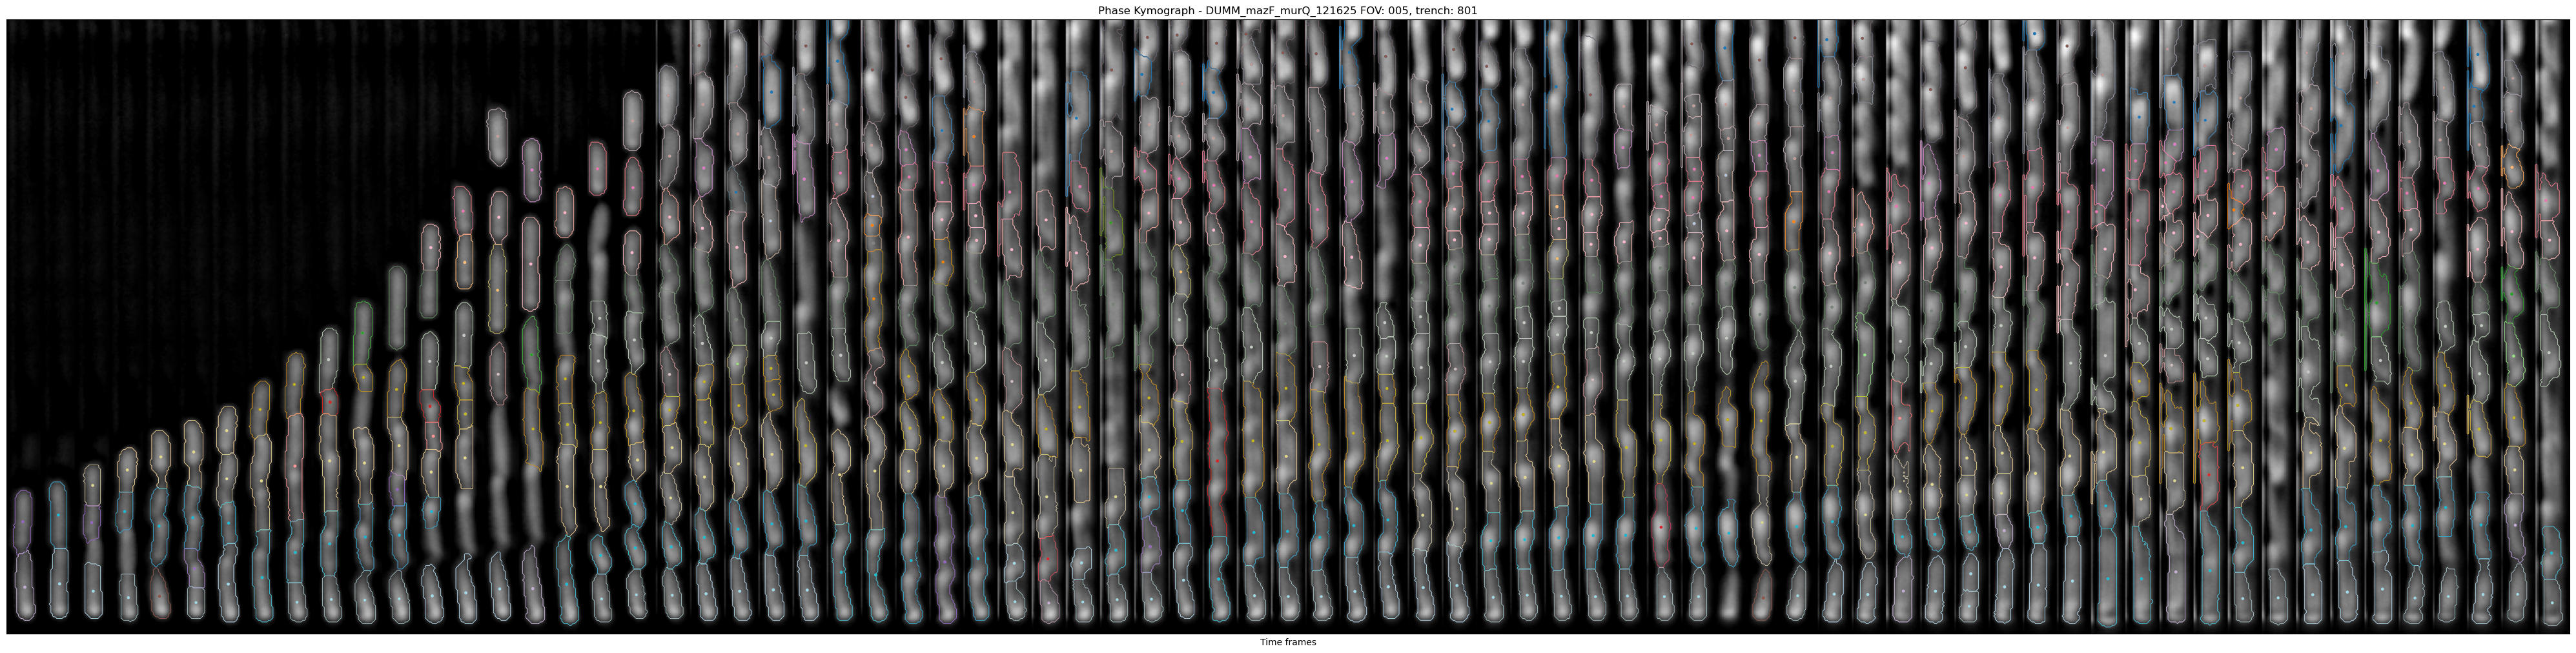

In [ ]:
# this is code i'm using to plot specific experiment/fov/trench
# uses all_lineages_df 
experiment_name = 'DUMM_mazF_murQ_121625'
fov = '005'
trench = '801'
filterd= all_lineages_df[all_lineages_df['experiment_name'] == experiment_name].copy()
kymo = filterd[(filterd['FOV'] == fov) & (filterd['trench_id'] == trench)].copy()
base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/'
plot_kymographs(base_dir, kymo)

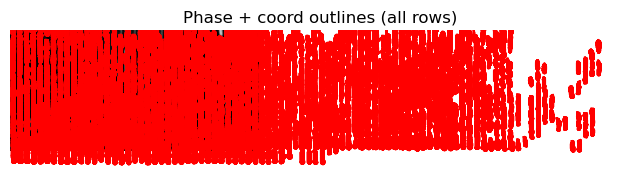

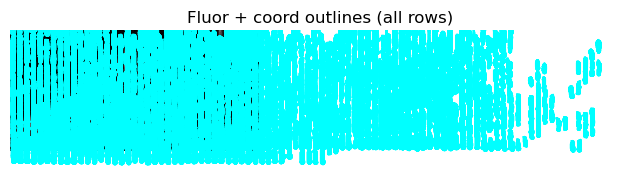

In [ ]:
base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/'
experiment_name = 'DUMM_mazF_murQ_121625'
subset = all_lineages_df[all_lineages_df['experiment_name'] == experiment_name]
fov = '005'
trench = '801'

### figure out where to go next here

kymo_base_path = os.path.join(
    base_dir, experiment_name, 'hyperstacked', 'drift_corrected', 'rotated',
    'mm_channels', 'subtracted'
)

path_to_phase_kymograph = os.path.join(kymo_base_path, f'{fov}_{trench}.tif')
path_to_fluor_kymograph = os.path.join(kymo_base_path, 'fluor_kymos', f'{fov}_{trench}.tif')

phase_kymograph = tifffile.imread(path_to_phase_kymograph)
fluor_kymograph = tifffile.imread(path_to_fluor_kymograph)

def plot_outline(ax, coords, color, lw=1.5):
    coords = np.asarray(coords)
    x = coords[:, 1]
    y = coords[:, 0]
    # close the polygon by repeating the first point at the end
    ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], color=color, linewidth=lw)

# ---- Phase ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(phase_kymograph, cmap="gray")

for _, row in subset.iterrows():
    plot_outline(ax, row['coords'], color="red", lw=1.5)

ax.set_title("Phase + coord outlines (all rows)")
ax.set_axis_off()
plt.show()

# ---- Fluor ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(fluor_kymograph, cmap="gray")

for _, row in subset.iterrows():
    plot_outline(ax, row['coords'], color="cyan", lw=1.5)

ax.set_title("Fluor + coord outlines (all rows)")
ax.set_axis_off()
plt.show()

In [ ]:
experiment = 'DUMM_gitg068_baeS_100225'
base_path =f'/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/{experiment}/hyperstacked/drift_corrected/rotated/mm_channels/subtracted'
path_to_mask = f'{base_path}/mm3_segmented_subtracted_FOV_018_region_1185_c_0.tif'
path_to_phase = f'{base_path}/subtracted_FOV_018_region_1185_c_0.tif'
imgs=tifffile.imread(path_to_phase)
masks=tifffile.imread(path_to_mask)

In [ ]:
base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/'

experiment_name = subset['experiment_name'].iloc[0]
trench_id = subset['trench_id'].iloc[0]
fov = subset['FOV'].iloc[0]

kymo_base_path = os.path.join(
    base_dir, experiment_name, 'hyperstacked', 'drift_corrected', 'rotated',
    'mm_channels', 'subtracted'
)

path_to_phase_kymograph = os.path.join(kymo_base_path, f'{fov}_{trench_id}.tif')
path_to_fluor_kymograph = os.path.join(kymo_base_path, 'fluor_kymos', f'{fov}_{trench_id}.tif')

phase_kymograph = tifffile.imread(path_to_phase_kymograph)
fluor_kymograph = tifffile.imread(path_to_fluor_kymograph)

def plot_outline(ax, coords, color, lw=1.5):
    coords = np.asarray(coords)
    x = coords[:, 1]
    y = coords[:, 0]
    # close the polygon by repeating the first point at the end
    ax.plot(np.r_[x, x[0]], np.r_[y, y[0]], color=color, linewidth=lw)

# ---- Phase ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(phase_kymograph, cmap="gray")

for _, row in subset.iterrows():
    plot_outline(ax, row['coords'], color="red", lw=1.5)

ax.set_title("Phase + coord outlines (all rows)")
ax.set_axis_off()
plt.show()

# ---- Fluor ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(fluor_kymograph, cmap="gray")

for _, row in subset.iterrows():
    plot_outline(ax, row['coords'], color="cyan", lw=1.5)

ax.set_title("Fluor + coord outlines (all rows)")
ax.set_axis_off()
plt.show()

In [ ]:
track_ided = all_lineages_df[all_lineages_df['track_id'].notnull()].copy()
print(track_ided['experiment_name'].unique())
experiment_name = 'DUMM_giTG059_noKan_Glucose_031125'
filterd= all_lineages_df[all_lineages_df['experiment_name'] == experiment_name].copy()
cell1 = filterd[filterd['unique_node_id'] == 'df1_6064'].copy()
base_dir = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data/'
plot_kymographs(base_dir, filterd)

In [ ]:
coords1 = cell1["coords"].iloc[0]
fov = cell1["FOV"].iloc[0]
trench_id = cell1["trench_id"].iloc[0]
experiment_name = cell1["experiment_name"].iloc[0]

In [ ]:

kymo_base_path = os.path.join(base_dir, experiment_name, 'hyperstacked', 'drift_corrected', 'rotated', 'mm_channels','subtracted')

path_to_phase_kymograph = os.path.join(kymo_base_path, f'{fov}_{trench_id}.tif')
path_to_fluor_kymograph = os.path.join(kymo_base_path, 'fluor_kymos', f'{fov}_{trench_id}.tif')  # Assuming 'fluor' subdirectory

phase_kymograph = tifffile.imread(path_to_phase_kymograph)
fluor_kymograph = tifffile.imread(path_to_fluor_kymograph)

coords = np.asarray(coords1)

x = coords[:, 1]
y = coords[:, 0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(phase_kymograph, cmap="gray")
ax.scatter(x, y, s=15, c="red", marker="o", linewidths=0)
ax.set_title("Phase + coords")
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(fluor_kymograph, cmap="gray")
ax.scatter(x, y, s=15, c="cyan", marker="o", linewidths=0)
ax.set_title("Fluor + coords")
ax.set_axis_off()
plt.show()